Training samples: 4800  Testing samples: 1200
Prior probabilities: [0.506 0.494]
Class-wise Mean of each feature:
Intensity  Non-Boundary = 0.4618  Boundary = 0.4408
Gradient  Non-Boundary = 0.285  Boundary = 0.5689
LocalMean  Non-Boundary = 0.4612  Boundary = 0.4473
LocalStd  Non-Boundary = 0.0503  Boundary = 0.0987
Laplacian  Non-Boundary = 0.0902  Boundary = 0.1461
Range  Non-Boundary = 0.1181  Boundary = 0.211
Accuracy: 0.6192
Confusion Matrix:
[[498  73]
 [384 245]]
              precision    recall  f1-score   support

Non-Boundary       0.56      0.87      0.69       571
    Boundary       0.77      0.39      0.52       629

    accuracy                           0.62      1200
   macro avg       0.67      0.63      0.60      1200
weighted avg       0.67      0.62      0.60      1200

Sample 0  P(Non-Boundary) = 0.9105  P(Boundary) = 0.0895  Predicted = 0  Actual = 0
Sample 1  P(Non-Boundary) = 0.8891  P(Boundary) = 0.1109  Predicted = 0  Actual = 0
Sample 2  P(Non-Boundary) = 0

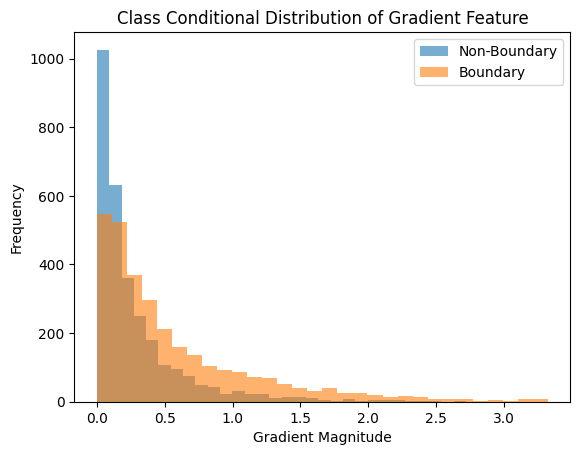

In [1]:
import os
import glob
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from scipy.io import loadmat
from scipy.ndimage import uniform_filter, sobel, laplace, maximum_filter, minimum_filter
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import kagglehub

path = kagglehub.dataset_download("balraj98/berkeley-segmentation-dataset-500-bsds500")

images = sorted(glob.glob(path + "/**/*.jpg", recursive=True))
gtmap = {}
for m in glob.glob(path + "/**/*.mat", recursive=True):
    gtmap[os.path.basename(m)[:-4]] = m

names = ["Intensity", "Gradient", "LocalMean", "LocalStd", "Laplacian", "Range"]


def get_features(f):
    g = np.array(Image.open(f).convert("L"), dtype=float) / 255.0
    gx = sobel(g, axis=0)
    gy = sobel(g, axis=1)
    grad = np.sqrt(gx * gx + gy * gy)
    mean = uniform_filter(g, 5)
    std = np.sqrt(np.abs(uniform_filter(g * g, 5) - mean * mean))
    lap = np.abs(laplace(g))
    rng = maximum_filter(g, 3) - minimum_filter(g, 3)
    F = np.stack([g, grad, mean, std, lap, rng], axis=2)
    return F.reshape(-1, 6), g.shape


def get_labels(name, shape):
    d = loadmat(gtmap[name])["groundTruth"]
    b = np.zeros(shape)
    for i in range(d.shape[1]):
        b = b + d[0, i]["Boundaries"][0, 0]
    return (b > 0).astype(int).reshape(-1)


def build_dataset(n_images, per_class):
    X = []
    Y = []
    for f in images[:n_images]:
        name = os.path.basename(f)[:-4]
        if name not in gtmap:
            continue
        F, shape = get_features(f)
        L = get_labels(name, shape)
        pos = np.where(L == 1)[0]
        neg = np.where(L == 0)[0]
        k = min(per_class, len(pos), len(neg))
        if k == 0:
            continue
        pos = np.random.choice(pos, k, replace=False)
        neg = np.random.choice(neg, k, replace=False)
        idx = np.concatenate([pos, neg])
        X.append(F[idx])
        Y.append(L[idx])
    return np.vstack(X), np.concatenate(Y)


np.random.seed(1)
X, y = build_dataset(30, 100)
Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.2, random_state=42)

print("Training samples:", len(Xtr), " Testing samples:", len(Xte))

model = GaussianNB()
model.fit(Xtr, ytr)
pred = model.predict(Xte)

print("Prior probabilities:", np.round(model.class_prior_, 4))
print("Class-wise Mean of each feature:")
for i in range(len(names)):
    print(names[i], " Non-Boundary =", round(model.theta_[0][i], 4), " Boundary =", round(model.theta_[1][i], 4))

print("Accuracy:", round(accuracy_score(yte, pred), 4))
cm = confusion_matrix(yte, pred)
print("Confusion Matrix:")
print(cm)
print(classification_report(yte, pred, target_names=["Non-Boundary", "Boundary"]))

prob = model.predict_proba(Xte)
for i in range(5):
    print("Sample", i, " P(Non-Boundary) =", round(prob[i][0], 4), " P(Boundary) =", round(prob[i][1], 4), " Predicted =", pred[i], " Actual =", yte[i])

plt.hist(X[y == 0][:, 1], bins=30, alpha=0.6, label="Non-Boundary")
plt.hist(X[y == 1][:, 1], bins=30, alpha=0.6, label="Boundary")
plt.xlabel("Gradient Magnitude")
plt.ylabel("Frequency")
plt.title("Class Conditional Distribution of Gradient Feature")
plt.legend()
plt.show()
